# Soft bosons — pairwise penetrable-sphere gas in 3D (PBC)

`N` bosons interacting through a **penetrable-sphere** (soft-core step) pair potential

$$ V = V_0 \sum_{i<j} \theta(R - r_{ij}), \qquad r_{ij} = |\mathrm{min\_image}(\mathbf r_i - \mathbf r_j)| $$

in a cubic periodic box. The step is *penetrable* (finite height `V0`): particles may overlap at a
finite cost, so there is no hard-core divergence and the wavefunction stays smooth / NN-friendly.

This notebook is a **parameterised setup** for studying the gas as a control parameter is varied
(interaction height `V0`, range `R`, or number density `ρ = N/L³`). It:
1. builds the `PenetrableSphereHamiltonian` (works in any `n_dim`; here `n_dim=3`),
2. trains a periodic `DeepSet` ansatz with the box (PBC) sampler,
3. measures energy-per-particle and the 3-D pair correlation `g(r)`,
4. wraps it in `run_soft(...)` so you can scan your parameter.

Hamiltonian: `qvarnet.PenetrableSphereHamiltonian` (kinetic `-½∇²`, min-image interactions).

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from qvarnet import PenetrableSphereHamiltonian, PeriodicBoundary
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.deep_set import DeepSet
from qvarnet.config.training_setup import TrainingConfig, SamplingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.train import train
from qvarnet.samplers import sample_and_process
from qvarnet.vmc.probability import build_prob_fn
from dilute_gas import get_x

## 0. Parameters

`ρ = N/L³` is the number density; `R` the interaction range; `V0` the interaction height. Natural
control parameters: `ρR³` (how many particles share an interaction volume) and `V0` (in units of
the kinetic scale `ħ²/mR² = 1/R²` here). Change `V0` (or `L`/`N`/`R`) and re-run to study the gas.

In [2]:
N      = 8          # number of bosons
N_DIM  = 3          # spatial dimensions (this notebook verifies the full 3-D pipeline)
L      = 3.0        # cubic box side (PBC)
R      = 1.0        # interaction range
V0     = 2.0        # interaction height (THE scan knob, by default)

rho = N / L**N_DIM
print(f"N={N} bosons in {N_DIM}D, L={L}  ->  density rho = N/L^{N_DIM} = {rho:.3f}")
print(f"R={R}, V0={V0}   ->  rho*R^{N_DIM} = {rho*R**N_DIM:.3f}  (particles per interaction volume ~ {rho*4/3*np.pi*R**3:.2f})")

N=8 bosons in 3D, L=3.0  ->  density rho = N/L^3 = 0.296
R=1.0, V0=2.0   ->  rho*R^3 = 0.296  (particles per interaction volume ~ 1.24)


## 1. Ansatz and Hamiltonian

Permutation-invariant `DeepSet` on the periodic (sin/cos) encoding — it can represent both a uniform
superfluid and a density-modulated (cluster) state. `PenetrableSphereHamiltonian` with
`boundary=PeriodicBoundary(L)` supplies the min-image interactions; `n_dim=N_DIM` makes it 3-D.

In [3]:
boundary = PeriodicBoundary(L=L)

def make_model():
    return LogWavefunction(
        n_particles=N, n_dim=N_DIM, transform=boundary,
        network=DeepSet(phi_hidden=[64], F_hidden=[64]),
    )

def make_hamiltonian(V0, R, boundary):
    return PenetrableSphereHamiltonian(n_dim=N_DIM, R=R, V0=V0, boundary=boundary)

## 2. Train (box / PBC sampler)

The box sampler (`box_L=L`) keeps walkers in one cell; `is_update_step_size` adapts the step to the
target acceptance. (For deeper/cluster regimes, switch to `sampler="pt"` for robustness.)

Running soft bosons with V0=2.0, R=1.0, L=3.0, N=8.
IMPORTANT: the constant gas x = 0.015


  0%|          | 0/400 [00:00<?, ?it/s]

 38%|███▊      | 152/400 [03:44<06:06,  1.48s/it, E=7.9100, sigma_E=2.9608]


Signal received, stopping after current step.
E = 8.0262 ± 0.0100    E/N = 1.0033


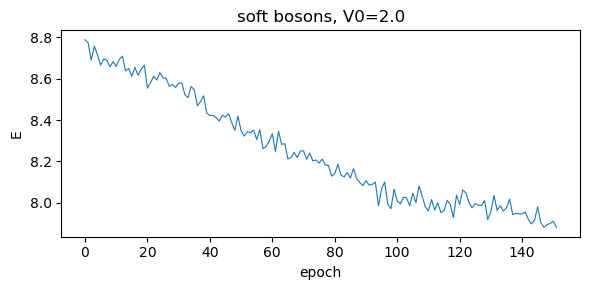

In [6]:
def run_soft(V0, R=R, L=L, N=N, n_epochs=400, n_chains=512, seed=0, sampler="mh"):
    """Train the soft-boson gas at (V0, R, L, N). Returns (result, E_mean, E_err)."""
    print(f"Running soft bosons with V0={V0}, R={R}, L={L}, N={N}.")
    print(f"IMPORTANT: the constant gas x = {get_x(V0, R, L, N):.3f}")
    bd = PeriodicBoundary(L=L)
    model = LogWavefunction(n_particles=N, n_dim=N_DIM, transform=bd,
                            network=DeepSet(phi_hidden=[64], F_hidden=[64]))
    sc = SamplingConfig(step_size=0.3, chain_length=80, thermalization_steps=20,
                        thinning_factor=2, box_L=L, sampler=sampler,
                        pt_n_replicas=6, pt_beta_min=0.05)
    result = train(
        shape=(n_chains, N * N_DIM), model=model, optimizer=optax.adam(3e-3),
        hamiltonian=PenetrableSphereHamiltonian(n_dim=N_DIM, R=R, V0=V0, boundary=bd),
        training_config=TrainingConfig(n_epochs=n_epochs, rng_seed=seed, is_update_step_size=True,
                                       target_acceptance=0.5, checkpoint_path="./checkpoints/soft"),
        sampler_params=sc, coord_mode=LabCoords())
    e = np.array([float(s.energy) for s in result.history])
    tail = e[-max(50, n_epochs // 5):]
    return result, float(tail.mean()), float(tail.std() / np.sqrt(len(tail)))

result, E, Eerr = run_soft(V0)
print(f"E = {E:.4f} ± {Eerr:.4f}    E/N = {E/N:.4f}")
energies = np.array([float(s.energy) for s in result.history])
plt.figure(figsize=(6, 3)); plt.plot(energies, lw=0.8)
plt.xlabel("epoch"); plt.ylabel("E"); plt.title(f"soft bosons, V0={V0}"); plt.tight_layout(); plt.show()

## 3. Pair correlation g(r) (3-D, PBC)

`g(r)` is the structural fingerprint: a flat `g(r)≈1` is a uniform gas; a peak at small `r` signals
clustering/correlation. We sample from the trained `|ψ|²`, take all min-image pair distances
(`r ≤ L/2`), and normalise by the ideal-gas shell `(N/2)·ρ·4πr²dr`.

In [ ]:
def sample_positions(params, L=L, N=N, n_chains=1000, n_steps=400, seed=11):
    pf = build_prob_fn(make_model().apply)
    x0 = jax.random.uniform(jax.random.PRNGKey(seed), (n_chains, N * N_DIM)) * L
    s, _, _ = sample_and_process(key=jax.random.PRNGKey(seed + 1), prob_fn=pf, prob_params=params,
                                 init_positions=x0, step_size=0.3, n_chains=n_chains, dof=N * N_DIM,
                                 n_steps=n_steps, burn_in=150, thinning=2, box_L=L)
    return np.asarray(s).reshape(-1, N, N_DIM)

def g_of_r(positions, L=L, N=N, bins=40):
    rmax = L / 2
    i, j = np.triu_indices(N, k=1)
    dx = positions[:, i, :] - positions[:, j, :]          # (M, n_pairs, d)
    dx -= L * np.round(dx / L)                              # minimum image
    d = np.sqrt((dx**2).sum(-1)).ravel()
    d = d[d < rmax]
    hist, edges = np.histogram(d, bins=bins, range=(0, rmax))
    centers = 0.5 * (edges[1:] + edges[:-1]); dr = edges[1] - edges[0]
    rho = N / L**3
    shell = 4 * np.pi * centers**2 * dr                    # ideal-gas shell volume
    M = positions.shape[0]
    g = hist / (M * (N / 2) * rho * shell)
    return centers, g

pos = sample_positions(result.best_params())
r, g = g_of_r(pos)
plt.figure(figsize=(6, 3)); plt.plot(r, g, "-o", ms=3); plt.axhline(1, color="k", ls="--", lw=0.7)
plt.axvline(R, color="r", ls=":", lw=0.8, label="R")
plt.xlabel("r"); plt.ylabel("g(r)"); plt.legend(); plt.title("pair correlation"); plt.tight_layout(); plt.show()
print(f"g(r) at contact (first bin) = {g[0]:.3f}   (depleted below 1 => soft correlation hole)")

## 4. Scan your parameter

`run_soft(V0=...)` (or vary `R`, `L`, `N`) is the unit of a parameter study. Below is a tiny
illustrative sweep over `V0` — extend the list, raise `n_epochs`/`n_chains`, and add seeds for
production. (For strongly clustered regimes, pass `sampler="pt"`.)

In [ ]:
V0_scan = [0.5, 2.0, 8.0]
rows = []
for v in V0_scan:
    res_v, E_v, err_v = run_soft(v, n_epochs=300, n_chains=512)
    r_v, g_v = g_of_r(sample_positions(res_v.best_params(), n_chains=800))
    rows.append((v, E_v / N, err_v / N, g_v[0]))
    print(f"V0={v:5.2f}  E/N={E_v/N:.4f} ± {err_v/N:.4f}   g(0)={g_v[0]:.3f}")

vs = [x[0] for x in rows]
plt.figure(figsize=(6, 3))
plt.errorbar(vs, [x[1] for x in rows], yerr=[x[2] for x in rows], fmt="-o")
plt.xlabel("V0"); plt.ylabel("E / N"); plt.title("energy per particle vs interaction height")
plt.tight_layout(); plt.show()

## Notes / next steps
- The `PenetrableSphereHamiltonian` works in any `n_dim` — change `N_DIM` for 1-D/2-D studies.
- The energy alone is a weak probe; `g(r)` (and `S(k)`) reveal structure. For the
  superfluid→supersolid/cluster question, add `S(k)` (diagonal order) and the OBDM / condensate
  fraction `n₀` (off-diagonal order) from the **same** wavefunction.
- A translation-invariant **3-D pairwise Jastrow** (correlation hole at `r<R`) would improve the
  variational energy for the uniform gas — the shipped `LogJastrow` is 1-D only, so a 3-D version
  is the natural next addition.
- Validate energies/`g(r)` against your DMC/eGPE references before drawing physics conclusions.